<h2>Linear regression model</h2>

### Import 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures

### Answers 

![Снимок экрана 2026-04-08 в 16.59.09.png](<attachment:Снимок экрана 2026-04-08 в 16.59.09.png>)
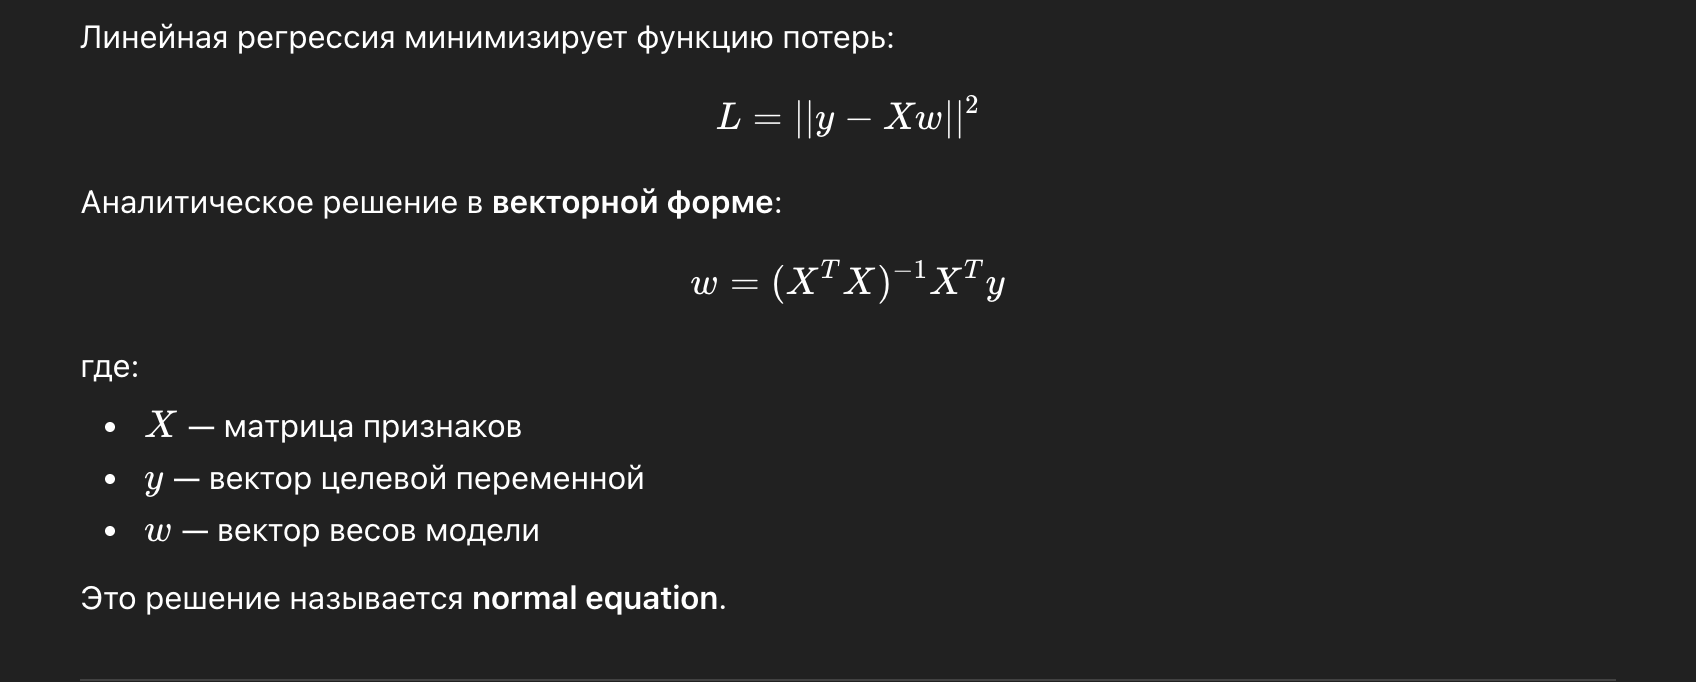

![Снимок экрана 2026-04-08 в 16.59.38.png](<attachment:Снимок экрана 2026-04-08 в 16.59.38.png>) ![Снимок экрана 2026-04-08 в 16.59.44.png](<attachment:Снимок экрана 2026-04-08 в 16.59.44.png>) ![Снимок экрана 2026-04-08 в 16.59.51.png](<attachment:Снимок экрана 2026-04-08 в 16.59.51.png>)
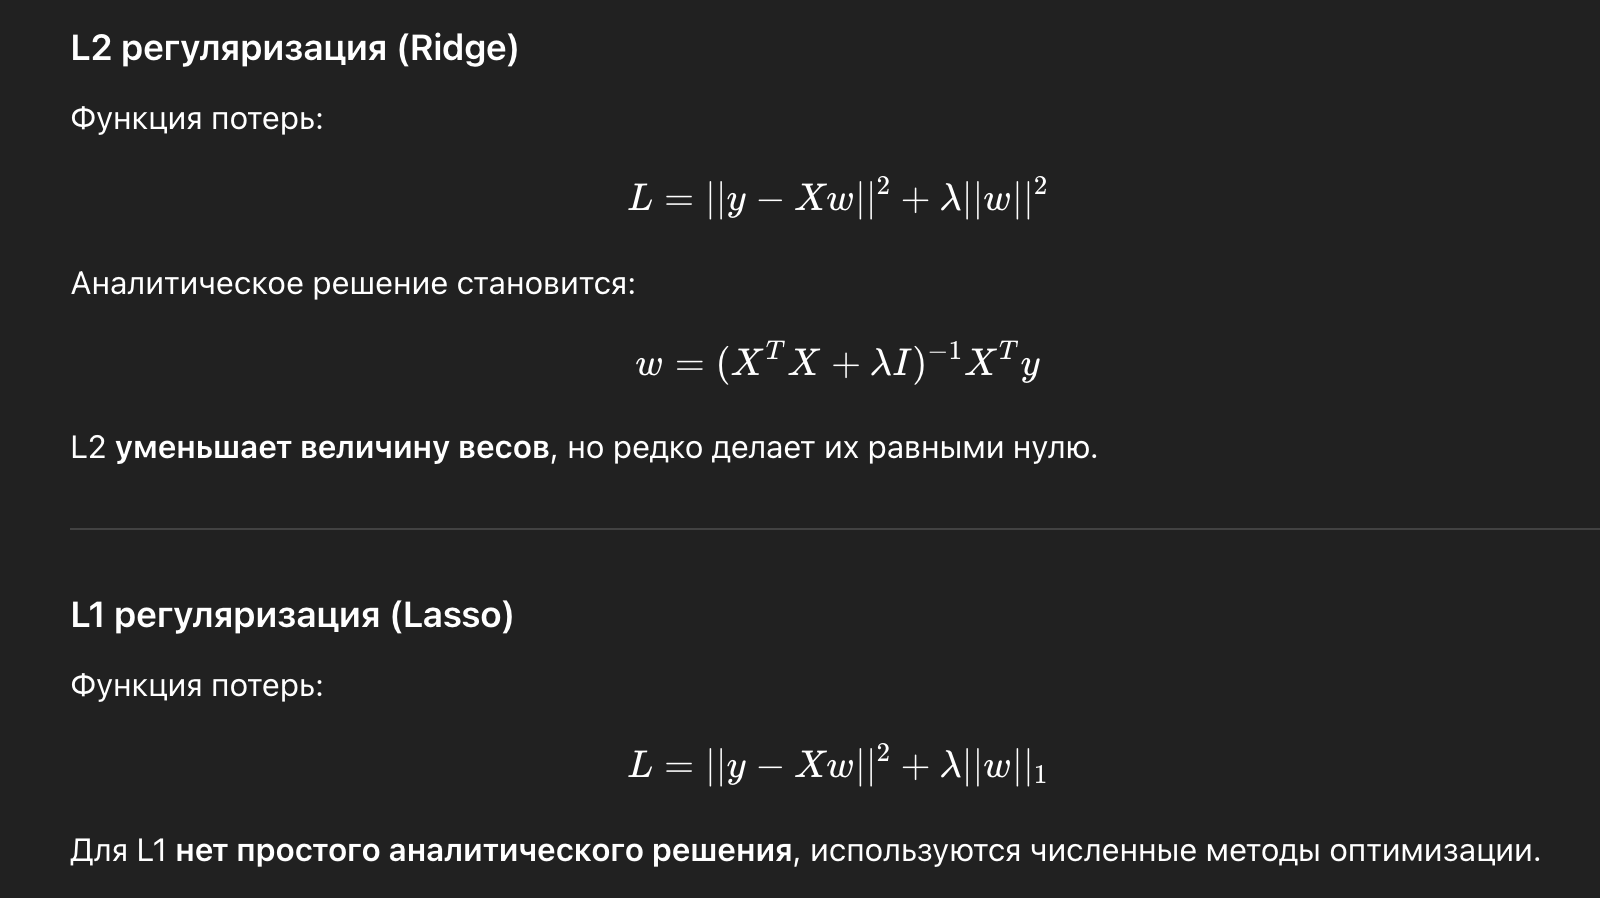
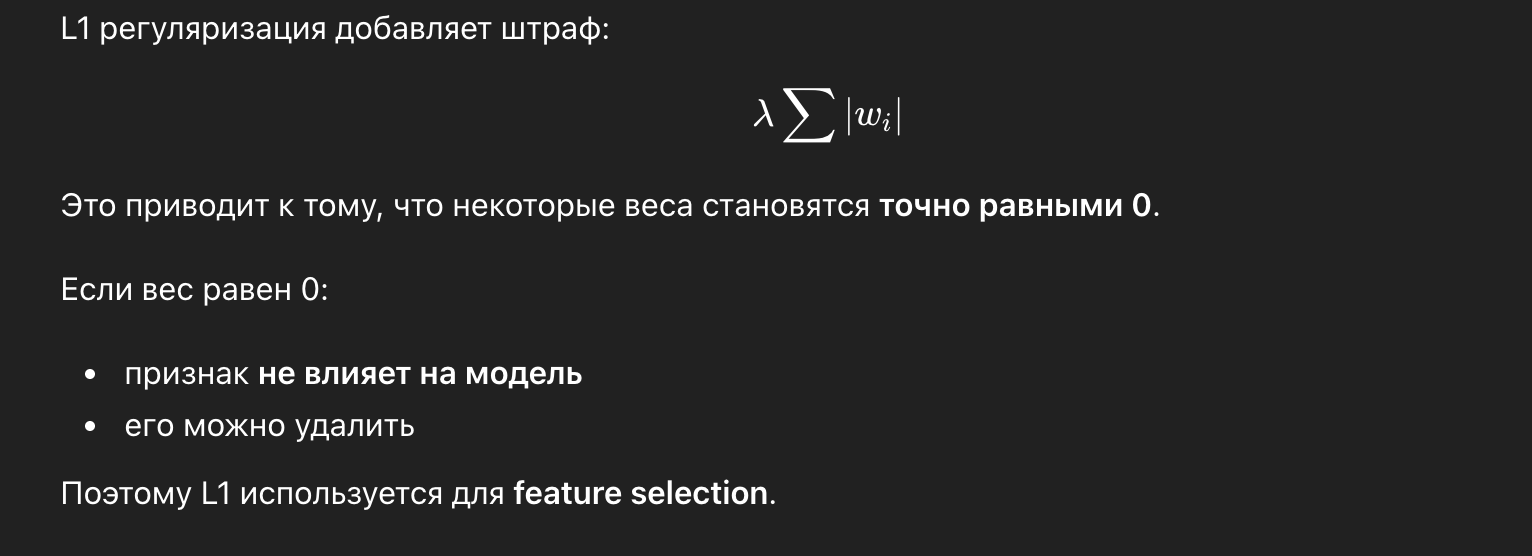
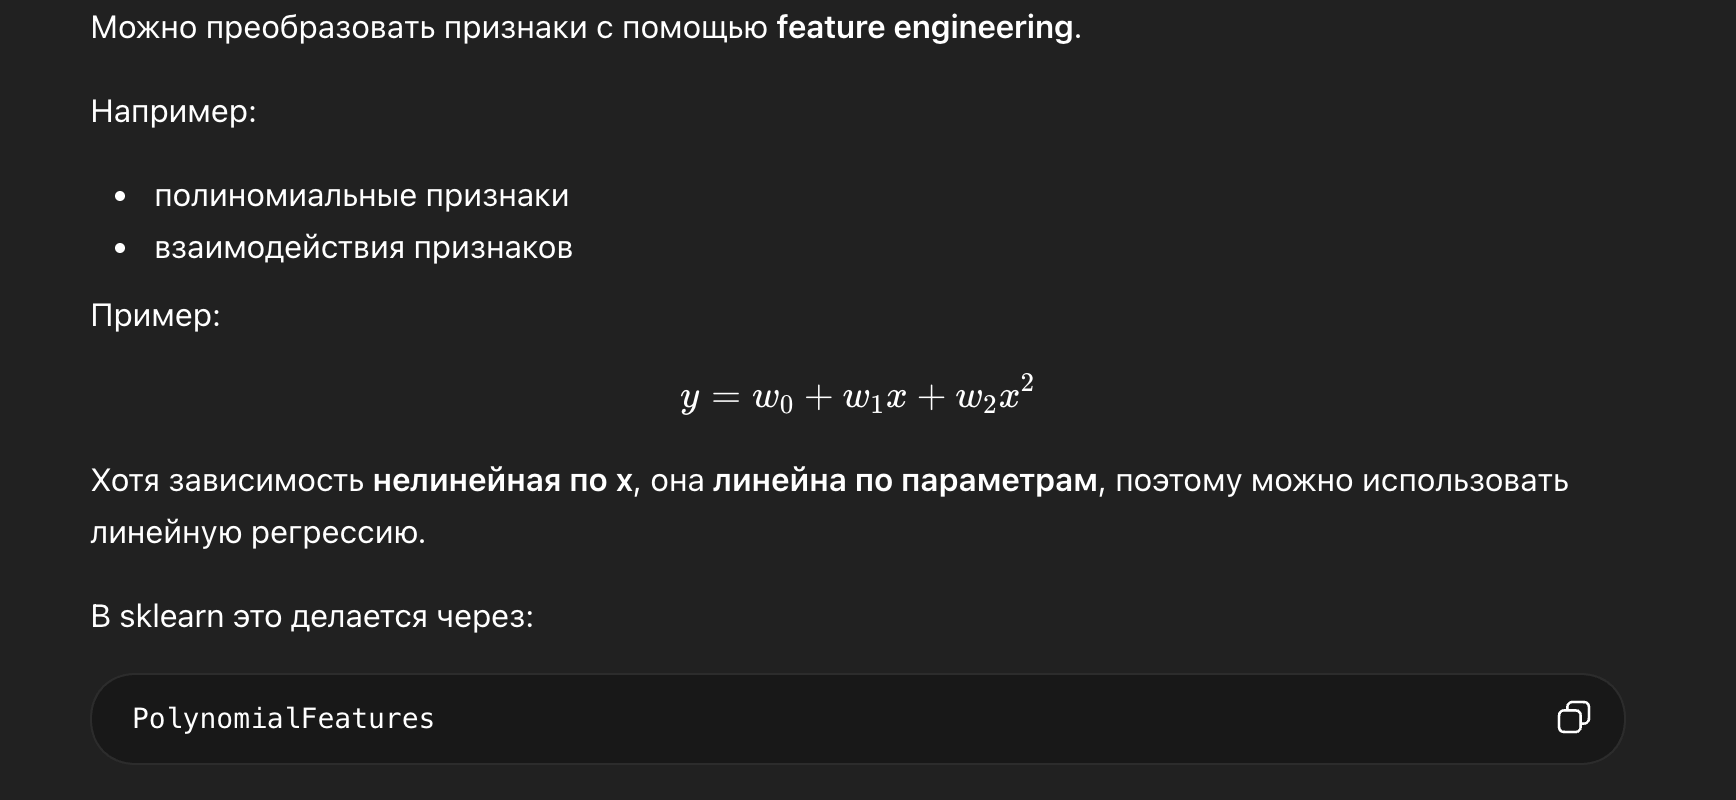

### Preprocessing

#### Introduction 

In [253]:
df_train = pd.read_json("data/train.json")
df_test = pd.read_json("data/test.json")
df_train


,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,92bbbf38baadfde0576fc496bd41749c,2016-04-05 03:58:33,There is 700 square feet of recently renovated...,W 171 Street,"[Elevator, Dishwasher, Hardwood Floors]",40.8433,6824800,-73.9396,a61e21da3ba18c7a3d54cfdcc247e1f8,[https://photos.renthop.com/2/6824800_0682be16...,2800,620 W 171 Street,low
124002,1.0,2,5565db9b7cba3603834c4aa6f2950960,2016-04-02 02:25:31,"2 bedroom apartment with updated kitchen, rece...",Broadway,"[Common Outdoor Space, Cats Allowed, Dogs Allo...",40.8198,6813268,-73.9578,8f90e5e10e8a2d7cf997f016d89230eb,[https://photos.renthop.com/2/6813268_1e6fcc32...,2395,3333 Broadway,medium
124004,1.0,1,67997a128056ee1ed7d046bbb856e3c7,2016-04-26 05:42:03,No Brokers Fee * Never Lived 1 Bedroom 1 Bathr...,210 Brighton 15th St,"[Dining Room, Elevator, Pre-War, Laundry in Bu...",40.5765,6927093,-73.9554,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/6927093_93a52104...,1850,210 Brighton 15th St,medium
124008,1.0,2,3c0574a740154806c18bdf1fddd3d966,2016-04-19 02:47:33,Wonderful Bright Chelsea 2 Bedroom apartment o...,West 21st Street,"[Pre-War, Laundry in Unit, Dishwasher, No Fee,...",40.7448,6892816,-74.0017,c3cd45f4381ac371507090e9ffabea80,[https://photos.renthop.com/2/6892816_1a8d087a...,4195,350 West 21st Street,medium


#### Intro data analysis part 2

Что такое  `детерминированная модель`?

`Детерминированная модель` - это модель, которая при одинаковых входных данных выдает всегда один и тот же вывод.

In [254]:
df_train["features"]

4         [Dining Room, Pre-War, Laundry in Building, Di...
6         [Doorman, Elevator, Laundry in Building, Dishw...
9         [Doorman, Elevator, Laundry in Building, Laund...
10                                                       []
15        [Doorman, Elevator, Fitness Center, Laundry in...
                                ...                        
124000              [Elevator, Dishwasher, Hardwood Floors]
124002    [Common Outdoor Space, Cats Allowed, Dogs Allo...
124004    [Dining Room, Elevator, Pre-War, Laundry in Bu...
124008    [Pre-War, Laundry in Unit, Dishwasher, No Fee,...
124009    [Dining Room, Elevator, Laundry in Building, D...
Name: features, Length: 49352, dtype: object

In [255]:

df_train["features"] = (
    df_train["features"]
    .astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("'", "", regex=False)
    .str.replace('"', "", regex=False)
    .str.split(",")
    .apply(lambda x: [i.strip() for i in x if i.strip()])
)

In [256]:
df_test["features"] = (
    df_test["features"]
    .astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("'", "", regex=False)
    .str.replace('"', "", regex=False)
    .str.split(",")
    .apply(lambda x: [i.strip() for i in x if i.strip()])
)

df_test.head(5)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address
0,1.0,1,79780be1514f645d7e6be99a3de696c5,2016-06-11 05:29:41,Large with awesome terrace--accessible via bed...,Suffolk Street,"[Elevator, Laundry in Building, Laundry in Uni...",40.7185,7142618,-73.9865,b1b1852c416d78d7765d746cb1b8921f,[https://photos.renthop.com/2/7142618_1c45a2c8...,2950,99 Suffolk Street
1,1.0,2,0,2016-06-24 06:36:34,Prime Soho - between Bleecker and Houston - Ne...,Thompson Street,"[Pre-War, Dogs Allowed, Cats Allowed]",40.7278,7210040,-74.0000,d0b5648017832b2427eeb9956d966a14,[https://photos.renthop.com/2/7210040_d824cc71...,2850,176 Thompson Street
2,1.0,0,0,2016-06-17 01:23:39,Spacious studio in Prime Location. Cleanbuildi...,Sullivan Street,"[Pre-War, Dogs Allowed, Cats Allowed]",40.7260,7174566,-74.0026,e6472c7237327dd3903b3d6f6a94515a,[https://photos.renthop.com/2/7174566_ba3a35c5...,2295,115 Sullivan Street
3,1.0,2,f9c826104b91d868e69bd25746448c0c,2016-06-21 05:06:02,For immediate access call Bryan.<br /><br />Bo...,Jones Street,"[Hardwood Floors, Dogs Allowed, Cats Allowed]",40.7321,7191391,-74.0028,41735645e0f8f13993c42894023f8e58,[https://photos.renthop.com/2/7191391_8c2f2d49...,2900,23 Jones Street
5,1.0,1,81062936e12ee5fa6cd2b965698e17d5,2016-06-16 07:24:27,Beautiful TRUE 1 bedroom in a luxury building ...,Exchange Place,"[Roof Deck, Doorman, Elevator, Fitness Center,...",40.7054,7171695,-74.0095,a742cf7dd3b2627d83417bc3a1b3ec96,[https://photos.renthop.com/2/7171695_089ffee2...,3254,20 Exchange Place


In [257]:
features = []

for index, row in df_train.iterrows():
    features.extend(row["features"])


features

['Dining Room',
 'Pre-War',
 'Laundry in Building',
 'Dishwasher',
 'Hardwood Floors',
 'Dogs Allowed',
 'Cats Allowed',
 'Doorman',
 'Elevator',
 'Laundry in Building',
 'Dishwasher',
 'Hardwood Floors',
 'No Fee',
 'Doorman',
 'Elevator',
 'Laundry in Building',
 'Laundry in Unit',
 'Dishwasher',
 'Hardwood Floors',
 'Doorman',
 'Elevator',
 'Fitness Center',
 'Laundry in Building',
 'Doorman',
 'Elevator',
 'Loft',
 'Dishwasher',
 'Hardwood Floors',
 'No Fee',
 'Fireplace',
 'Laundry in Unit',
 'Dishwasher',
 'Hardwood Floors',
 'No Fee',
 'Elevator',
 'Laundry in Building',
 'Dishwasher',
 'Hardwood Floors',
 'No Fee',
 'Hardwood Floors',
 'Cats Allowed',
 'Dogs Allowed',
 'Doorman',
 'Elevator',
 'Laundry in Building',
 'Dogs Allowed',
 'Cats Allowed',
 'Roof Deck',
 'Doorman',
 'Elevator',
 'Fitness Center',
 'Pre-War',
 'Laundry in Building',
 'High Speed Internet',
 'Dishwasher',
 'Hardwood Floors',
 'No Fee',
 'Dogs Allowed',
 'Cats Allowed',
 'Swimming Pool',
 'Roof Deck',
 '

In [ ]:
feature_counts = Counter(features)

In [259]:
unique_feature = list(feature_counts.keys())
len(unique_feature)

1554

In [260]:
sorted_features = feature_counts.most_common()

sorted_features

[('Elevator', 25915),
 ('Cats Allowed', 23540),
 ('Hardwood Floors', 23527),
 ('Dogs Allowed', 22035),
 ('Doorman', 20898),
 ('Dishwasher', 20426),
 ('No Fee', 18062),
 ('Laundry in Building', 16344),
 ('Fitness Center', 13252),
 ('Pre-War', 9148),
 ('Laundry in Unit', 8738),
 ('Roof Deck', 6542),
 ('Outdoor Space', 5268),
 ('Dining Room', 5136),
 ('High Speed Internet', 4299),
 ('Balcony', 2992),
 ('Swimming Pool', 2730),
 ('Laundry In Building', 2593),
 ('New Construction', 2559),
 ('Terrace', 2283),
 ('Exclusive', 2167),
 ('Loft', 2100),
 ('Garden/Patio', 1943),
 ('Wheelchair Access', 1358),
 ('Common Outdoor Space', 1293),
 ('HARDWOOD', 914),
 ('Fireplace', 912),
 ('SIMPLEX', 908),
 ('prewar', 855),
 ('LOWRISE', 789),
 ('Garage', 745),
 ('Laundry Room', 719),
 ('Reduced Fee', 699),
 ('Laundry In Unit', 697),
 ('Furnished', 689),
 ('Multi-Level', 622),
 ('Private Outdoor Space', 508),
 ('Prewar', 494),
 ('PublicOutdoor', 423),
 ('Parking Space', 418),
 ('Roof-deck', 397),
 ('dishwas

In [261]:
top_20 = sorted_features[:20]
top_20

[('Elevator', 25915),
 ('Cats Allowed', 23540),
 ('Hardwood Floors', 23527),
 ('Dogs Allowed', 22035),
 ('Doorman', 20898),
 ('Dishwasher', 20426),
 ('No Fee', 18062),
 ('Laundry in Building', 16344),
 ('Fitness Center', 13252),
 ('Pre-War', 9148),
 ('Laundry in Unit', 8738),
 ('Roof Deck', 6542),
 ('Outdoor Space', 5268),
 ('Dining Room', 5136),
 ('High Speed Internet', 4299),
 ('Balcony', 2992),
 ('Swimming Pool', 2730),
 ('Laundry In Building', 2593),
 ('New Construction', 2559),
 ('Terrace', 2283)]

In [262]:
for feature in top_20:
    df_train[feature[0]] = df_train["features"].apply(
        lambda x: 1 if feature[0] in x else 0 
    )


In [263]:
for feature in top_20:
    df_test[feature[0]] = df_test["features"].apply(
        lambda x: 1 if feature[0] in x else 0 
    )

df_test

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,...,Laundry in Unit,Roof Deck,Outdoor Space,Dining Room,High Speed Internet,Balcony,Swimming Pool,Laundry In Building,New Construction,Terrace
0,1.0,1,79780be1514f645d7e6be99a3de696c5,2016-06-11 05:29:41,Large with awesome terrace--accessible via bed...,Suffolk Street,"[Elevator, Laundry in Building, Laundry in Uni...",40.7185,7142618,-73.9865,...,1,0,1,0,0,0,0,0,0,0
1,1.0,2,0,2016-06-24 06:36:34,Prime Soho - between Bleecker and Houston - Ne...,Thompson Street,"[Pre-War, Dogs Allowed, Cats Allowed]",40.7278,7210040,-74.0000,...,0,0,0,0,0,0,0,0,0,0
2,1.0,0,0,2016-06-17 01:23:39,Spacious studio in Prime Location. Cleanbuildi...,Sullivan Street,"[Pre-War, Dogs Allowed, Cats Allowed]",40.7260,7174566,-74.0026,...,0,0,0,0,0,0,0,0,0,0
3,1.0,2,f9c826104b91d868e69bd25746448c0c,2016-06-21 05:06:02,For immediate access call Bryan.<br /><br />Bo...,Jones Street,"[Hardwood Floors, Dogs Allowed, Cats Allowed]",40.7321,7191391,-74.0028,...,0,0,0,0,0,0,0,0,0,0
5,1.0,1,81062936e12ee5fa6cd2b965698e17d5,2016-06-16 07:24:27,Beautiful TRUE 1 bedroom in a luxury building ...,Exchange Place,"[Roof Deck, Doorman, Elevator, Fitness Center,...",40.7054,7171695,-74.0095,...,0,1,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124003,1.0,1,bd863d28a6b119ac3bc72d5f27b07f24,2016-04-26 16:09:55,BRAND NEW TO MARKET 1BDR \r107TH AND LEXINGTON...,150 EAST 107TH STREET,[],40.7925,6928108,-73.9454,...,0,0,0,0,0,0,0,0,0,0
124005,1.0,2,9174b75c0cd978eb0e5aa93afbad754b,2016-04-21 05:06:19,Convertible 2BR apartment features a brand new...,E 33rd St.,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7456,6906674,-73.9797,...,0,0,0,0,0,0,0,0,0,0
124006,1.0,0,0,2016-04-20 01:31:52,"Let's get you in to see this $2,400/mo, recent...",Lexington Avenue,"[Dogs Allowed, Cats Allowed]",40.7416,6897967,-73.9829,...,0,0,0,0,0,0,0,0,0,0
124007,2.0,2,c90c010e5505365676538e64d02aa1e0,2016-04-08 02:26:45,CooperCooper.com :: Web ID #171357; Access 100...,Park Avenue,"[Doorman, Elevator, Cats Allowed, Dogs Allowed]",40.7485,6842183,-73.9800,...,0,0,0,0,0,0,0,0,0,0


In [264]:
top_20_copy = []

for i in top_20:
    top_20_copy.append(i[0])

top_20_copy

['Elevator',
 'Cats Allowed',
 'Hardwood Floors',
 'Dogs Allowed',
 'Doorman',
 'Dishwasher',
 'No Fee',
 'Laundry in Building',
 'Fitness Center',
 'Pre-War',
 'Laundry in Unit',
 'Roof Deck',
 'Outdoor Space',
 'Dining Room',
 'High Speed Internet',
 'Balcony',
 'Swimming Pool',
 'Laundry In Building',
 'New Construction',
 'Terrace']

In [265]:

feature_list = ["bathrooms", "bedrooms"] + top_20_copy

feature_list

['bathrooms',
 'bedrooms',
 'Elevator',
 'Cats Allowed',
 'Hardwood Floors',
 'Dogs Allowed',
 'Doorman',
 'Dishwasher',
 'No Fee',
 'Laundry in Building',
 'Fitness Center',
 'Pre-War',
 'Laundry in Unit',
 'Roof Deck',
 'Outdoor Space',
 'Dining Room',
 'High Speed Internet',
 'Balcony',
 'Swimming Pool',
 'Laundry In Building',
 'New Construction',
 'Terrace']

In [266]:
X_train = df_train[feature_list]
y_train = df_train["price"]

X_test = df_test[feature_list]
y_test = df_test["price"]

#### Models implementation — Linear regression

In [267]:
X_train.shape[1]

22

In [289]:
class LinearRegressionSGD:
    def __init__(self, lr=0.0001, epochs=1000, alpha=0.01,
             alpha1=0.01, alpha2=0.01,
             penalty=None, random_state=21):

        self.lr = lr
        self.epochs = epochs

        self.alpha = alpha
        self.alpha1 = alpha1
        self.alpha2 = alpha2

        self.penalty = penalty

        np.random.seed(random_state)
    
    def add_bias(self, X):
        X = X.to_numpy()
        X = np.c_[np.ones(X.shape[0]), X]
        return X

    def fit(self, X, y):

        X = self.add_bias(X)
        y = y.to_numpy()

        n_features = X.shape[1]

        self.w = np.random.randn(n_features)

        for _ in range(self.epochs):

            i = np.random.randint(0, X.shape[0])

            X_i = X[i]
            y_i = y[i]

            prediction = X_i @ self.w
            error = prediction - y_i

            if self.penalty is None:
                gradient = X_i * error

            elif self.penalty == "ridge":
                gradient = X_i * error + self.alpha * self.w

            elif self.penalty == "lasso":
                gradient = X_i * error + self.alpha * np.sign(self.w)

            elif self.penalty == "elasticnet":
                gradient = X_i * error + self.alpha1 * np.sign(self.w) + self.alpha2 * self.w

            self.w -= self.lr * gradient

        return self

    def predict(self, X):
        X = self.add_bias(X)

        return X @ self.w
    
    def evaluate(self, y_pred, y_true):

        mae = np.mean(np.abs(y_true.to_numpy() - y_pred))

        rmse = np.sqrt(np.mean((y_true.to_numpy() - y_pred) ** 2))

        ss_res = np.sum((y_true - y_pred)**2)

        ss_tot = np.sum((y_true - np.mean(y_true))**2)

        r2 = 1 - ss_res/ss_tot

        return mae, rmse, r2
    
    def marks(self, y_pred, y_true):
        mae, rmse, r2 = self.evaluate(y_pred, y_true)
        
        print(f"MAE: {mae}")
        print(f"RMSE: {rmse}")
        print(f"r2: {r2}")



class LinearRegressionAnalytical:

    def add_bias(self, X):
        
        X = X.to_numpy()
        X = np.c_[np.ones(X.shape[0]), X]
        return X

    def fit(self, X, y):
        
        X = self.add_bias(X)
        y = y.to_numpy(y)

        XTX = X.T @ X
        XTy = X.T @ y

        self.w = np.linalg.inv(XTX) @ XTy

        return self

    def predict(self, X):
        
        X = self.add_bias(X)

        return X @ self.w
    
    def evaluate(self, y_true, y_pred):

        mae  = np.mean(np.abs(y_true.to_numpy() - y_pred))

        rmse = np.sqrt(np.mean(y_true.to_numpy() - y_pred)**2)

        ss_res = np.sum((y_true - y_pred)**2)

        ss_tot = np.sum((y_true - np.mean(y_true))**2)

        r2 = 1 - ss_res/ss_tot

        print(f"MAE: {mae}")
        print(f"RMSE: {rmse}")
        print(f"R2: {r2}")
        



    

##### Analytical method

In [284]:
model_analytic = LinearRegressionAnalytical()

model_analytic.fit(X_train, y_train)

pred_an_train = model_analytic.predict(X_train)

pred_an_test = model_analytic.predict(X_test)

In [285]:
mae_an_train = mean_absolute_error(y_train, pred_an_train)
rmse_an_train = np.sqrt(np.mean((y_train.to_numpy() - pred_an_train) ** 2))
ss_res_train = np.sum((y_train - pred_an_train)**2)

ss_tot_train = np.sum((y_train - np.mean(y_train))**2)

r2_an_train = 1 - ss_res_train/ss_tot_train

mae_an_test = mean_absolute_error(y_test, pred_an_test)
rmse_an_test = np.sqrt(np.mean((y_test.to_numpy() - pred_an_test) ** 2))
ss_res_test = np.sum((y_test - pred_an_test)**2)

ss_tot_test = np.sum((y_test - np.mean(y_test))**2)

r2_an_test = 1 - ss_res_test/ss_tot_test


print(f"MAE train: {mae_an_train}")
print(f"MAE test: {mae_an_test}")

print()

print(f"RMSE train: {rmse_an_train}")
print(f"RMSE test: {mae_an_train}")

print()

print(f"R2 train: {r2_an_train}")
print(f"R2 test: {r2_an_test}")

MAE train: 1155.270725358084
MAE test: 1085.8255539561403

RMSE train: 21995.071938356763
RMSE test: 1155.270725358084

R2 train: 0.006476228991432853
R2 test: 0.019095638577382945


##### SGD method

In [269]:
model = LinearRegressionSGD()

model.fit(X_train, y_train)

pred_train = model.predict(X_train)

pred_test = model.predict(X_test)

In [270]:
model.marks(pred_train, y_train)

MAE: 1912.7178976245082
RMSE: 22112.959486752585
r2: -0.0042023410474389955


In [271]:
model.marks(pred_test, y_test)

MAE: 1832.6149114633033
RMSE: 9807.894289291631
r2: -0.01962951828430648


In [272]:
sk_model = LinearRegression()

sk_model.fit(X_train, y_train)

pred_sk_train = sk_model.predict(X_train)

pred_sk_test= sk_model.predict(X_test)

In [273]:
df_mae = pd.DataFrame(
    columns=["model", "train", "test"]
)

df_rmse = pd.DataFrame(
    columns=["model", "train", "test"]
)

df_r2 = pd.DataFrame(
    columns=["model", "train", "test"]
)

In [ ]:
mae_train, rmse_train, r2_train = model.evaluate(pred_train, y_train)
mae_test, rmse_test, r2_test = model.evaluate(pred_test, y_test)


mae_sk_train = mean_absolute_error(y_train, pred_sk_train)
rmse_sk_train = np.sqrt(np.mean((y_train.to_numpy() - pred_sk_train) ** 2))
ss_res_train = np.sum((y_train - pred_sk_train)**2)

ss_tot_train = np.sum((y_train - np.mean(y_train))**2)

r2_sk_train = 1 - ss_res_train/ss_tot_train

mae_sk_test = mean_absolute_error(y_test, pred_sk_test)
rmse_sk_test = np.sqrt(np.mean((y_test.to_numpy() - pred_sk_test) ** 2))
ss_res_test = np.sum((y_test - pred_sk_test)**2)

ss_tot_test = np.sum((y_test - np.mean(y_test))**2)

r2_sk_test = 1 - ss_res_test/ss_tot_test


df_mae.loc[len(df_mae)] = ['simple_model', mae_train, mae_test]
df_rmse.loc[len(df_rmse)] = ['simple_model', rmse_train, rmse_test]
df_r2.loc[len(df_r2)] = ['simple_model', r2_train, r2_test]


df_mae.loc[len(df_mae)] = ['sk_model', mae_sk_train, mae_sk_test]
df_rmse.loc[len(df_rmse)] = ['sk_model', rmse_sk_train, rmse_sk_test]
df_r2.loc[len(df_r2)] = ['sk_model', r2_sk_train, r2_sk_test]

In [276]:
df_mae

,model,train,test
0,simple_model,1912.717898,1832.614911
1,sk_model,1155.270725,1085.825554


In [277]:
df_rmse

,model,train,test
0,simple_model,22112.959487,9807.894289
1,sk_model,21995.071938,9619.841338


In [278]:
df_r2

,model,train,test
0,simple_model,-0.004202,-0.019630
1,sk_model,0.006476,0.019096


#### Regularized models implementation — Ridge, Lasso, ElasticNet

Реализация регуляризованных моделей — `Ridge`, `Lasso`, `ElasticNet`


Реализуйте алгоритмы Ridge, Lasso и ElasticNet: дополните функцию потерь регуляризацией L2, L1 и обеими регуляризациями.


Сделайте прогноз с помощью своего алгоритма и оцените модель с помощью метрик `MAE`, `RMSE` и `R2`.
Инициализируйте `Ridge()`, `Lasso()` и `ElasticNet()` из `sklearn.linear_model`, обучите модель и сделайте прогнозы для обучающей и тестовой выборок, как в предыдущем уроке.


Сравните показатели качества и убедитесь, что разница невелика (между вашими реализациями и реализациями из sklearn).


Сохраните метрики, как в предыдущем уроке, в таблице со столбцами model, train, test для таблицы MAE, RMSE и коэффициента R2.

##### Ridge, Lasso, ElasticNet

In [ ]:
def lasso_loss(X, y, w, alpha):

    y_pred = X @ w

    mse = np.mean((y_pred - y)**2)

    l1 = alpha * np.sum(np.abs(w))

    return mse + l1


def ridge_lasso(X, y, w, alpha):
    
    y_pred = X @ w

    mse = np.mean((y_pred - y)**2)

    l2 = alpha * np.sum(w**2)

    return mse + l2


def elasticnet_loss(X, y, w, alpha1, alpha2):

    y_pred = X @ w

    mse = np.mean((y_pred - y) ** 2)

    l1 = alpha1 * np.sum(np.abs(w))

    l2 = alpha2 * np.sum(w**2)

    return mse + l1 + l2



    


In [293]:
model_ridge = LinearRegressionSGD(penalty="ridge", alpha=0.01)

model_ridge.fit(X_train, y_train)

predict_ridge_train = model_ridge.predict(X_train)
predict_ridge_test = model_ridge.predict(X_test)


mae_ridge_train, rmse_ridge_train, r2_ridge_train = model_ridge.evaluate(predict_ridge_train, y_train)
mae_ridge_test, rmse_ridge_test, r2_ridge_test = model_ridge.evaluate(predict_ridge_train, y_train)

print(mae_ridge_train, rmse_ridge_train, r2_ridge_train)
print(mae_ridge_test, rmse_ridge_test, r2_ridge_test )


df_mae.loc[len(df_mae)] = ['model_ridge', mae_ridge_train, mae_ridge_test]
df_rmse.loc[len(df_rmse)] = ['model_ridge', rmse_ridge_train, rmse_ridge_test]
df_r2.loc[len(df_r2)] = ['model_ridge', r2_ridge_train, r2_ridge_test]

1913.5241055158529 22113.042523415537 -0.004209882848249746
1913.5241055158529 22113.042523415537 -0.004209882848249746


In [294]:
model_lasso = LinearRegressionSGD(penalty="lasso", alpha=0.01)

model_lasso.fit(X_train, y_train)

predict_lasso_train = model_lasso.predict(X_train)
predict_lasso_test = model_lasso.predict(X_test)


mae_lasso_train, rmse_lasso_train, r2_lasso_train = model_lasso.evaluate(predict_lasso_train, y_train)
mae_lasso_test, rmse_lasso_test, r2_lasso_test = model_lasso.evaluate(predict_lasso_train, y_train)

print(mae_lasso_train, rmse_lasso_train, r2_lasso_train)
print(mae_lasso_test, rmse_lasso_test, r2_lasso_test )


df_mae.loc[len(df_mae)] = ['model_lasso', mae_lasso_train, mae_lasso_test]
df_rmse.loc[len(df_rmse)] = ['model_lasso', rmse_lasso_train, rmse_lasso_test]
df_r2.loc[len(df_r2)] = ['model_lasso', r2_lasso_train, r2_lasso_test]

1912.7236187032122 22112.960043685238 -0.004202391630725222
1912.7236187032122 22112.960043685238 -0.004202391630725222


In [295]:
model_elasticnet = LinearRegressionSGD(
    penalty="elasticnet",
    alpha1=0.01,
    alpha2=0.01
)

model_elasticnet.fit(X_train, y_train)

predict_elasticnet_train = model_elasticnet.predict(X_train)
predict_elasticnet_test = model_elasticnet.predict(X_test)


mae_elasticnet_train, rmse_elasticnet_train, r2_elasticnet_train = model_elasticnet.evaluate(predict_elasticnet_train, y_train)
mae_elasticnet_test, rmse_elasticnet_test, r2_elasticnet_test = model_elasticnet.evaluate(predict_elasticnet_train, y_train)

print(mae_elasticnet_train, rmse_elasticnet_train, r2_elasticnet_train)
print(mae_elasticnet_test, rmse_elasticnet_test, r2_elasticnet_test )


df_mae.loc[len(df_mae)] = ['model_elasticnet', mae_elasticnet_train, mae_elasticnet_test]
df_rmse.loc[len(df_rmse)] = ['model_elasticnet', rmse_elasticnet_train, rmse_elasticnet_test]
df_r2.loc[len(df_r2)] = ['model_elasticnet', r2_elasticnet_train, r2_elasticnet_test]

1913.5298248524477 22113.04308036814 -0.004209933433538149
1913.5298248524477 22113.04308036814 -0.004209933433538149


In [296]:
df_mae

,model,train,test
0,simple_model,1912.717898,1832.614911
1,sk_model,1155.270725,1085.825554
2,model_ridge,1913.524106,1913.524106
3,model_lasso,1912.723619,1912.723619
4,model_elasticnet,1913.529825,1913.529825


In [297]:
df_rmse

,model,train,test
0,simple_model,22112.959487,9807.894289
1,sk_model,21995.071938,9619.841338
2,model_ridge,22113.042523,22113.042523
3,model_lasso,22112.960044,22112.960044
4,model_elasticnet,22113.043080,22113.043080


In [298]:
df_r2

,model,train,test
0,simple_model,-0.004202,-0.019630
1,sk_model,0.006476,0.019096
2,model_ridge,-0.004210,-0.004210
3,model_lasso,-0.004202,-0.004202
4,model_elasticnet,-0.004210,-0.004210


##### sklearn

In [301]:
ridge_sk = Ridge(alpha=0.01)

ridge_sk.fit(X_train, y_train)

ridge = Ridge(alpha=0.01)

ridge.fit(X_train, y_train)

pred_ridge_sk_train = ridge.predict(X_train)
pred_ridge_sk_test = ridge.predict(X_test)

mae_ridge_sk_train = mean_absolute_error(y_train, pred_ridge_sk_train)
mae_ridge_sk_test = mean_absolute_error(y_test, pred_ridge_sk_test)

rmse_ridge_sk_train = np.sqrt(np.mean((y_train - pred_ridge_sk_train)**2))
rmse_ridge_sk_test = np.sqrt(np.mean((y_test - pred_ridge_sk_test)**2))

ss_res_train = np.sum((y_train - pred_ridge_sk_train)**2)
ss_tot_train = np.sum((y_train - np.mean(y_train))**2)
r2_ridge_sk_train = 1 - ss_res_train / ss_tot_train

ss_res_test = np.sum((y_test - pred_ridge_sk_test)**2)
ss_tot_test = np.sum((y_test - np.mean(y_test))**2)
r2_ridge_sk_test = 1 - ss_res_test / ss_tot_test

df_mae.loc[len(df_mae)] = ['model_ridge_sk', mae_ridge_sk_train, mae_ridge_sk_test]
df_rmse.loc[len(df_rmse)] = ['model_ridge_sk', rmse_ridge_sk_train, rmse_ridge_sk_test]
df_r2.loc[len(df_r2)] = ['model_ridge_sk', r2_ridge_sk_train, r2_ridge_sk_test]





In [302]:
lasso_sk = Lasso(alpha=0.01)

lasso_sk.fit(X_train, y_train)

pred_lasso_sk_train = lasso_sk.predict(X_train)
pred_lasso_sk_test = lasso_sk.predict(X_test)

mae_lasso_sk_train = mean_absolute_error(y_train, pred_lasso_sk_train)
mae_lasso_sk_test = mean_absolute_error(y_test, pred_lasso_sk_test)

rmse_lasso_sk_train = np.sqrt(np.mean((y_train - pred_lasso_sk_train)**2))
rmse_lasso_sk_test = np.sqrt(np.mean((y_test - pred_lasso_sk_test)**2))

ss_res_train = np.sum((y_train - pred_lasso_sk_train)**2)
ss_tot_train = np.sum((y_train - np.mean(y_train))**2)
r2_lasso_sk_train = 1 - ss_res_train / ss_tot_train

ss_res_test = np.sum((y_test - pred_lasso_sk_test)**2)
ss_tot_test = np.sum((y_test - np.mean(y_test))**2)
r2_lasso_sk_test = 1 - ss_res_test / ss_tot_test

df_mae.loc[len(df_mae)] = ['model_lasso_sk', mae_lasso_sk_train, mae_lasso_sk_test]
df_rmse.loc[len(df_rmse)] = ['model_lasso_sk', rmse_lasso_sk_train, rmse_lasso_sk_test]
df_r2.loc[len(df_r2)] = ['model_lasso_sk', r2_lasso_sk_train, r2_lasso_sk_test]

In [303]:
elastic_sk = ElasticNet(alpha=0.01)

elastic_sk.fit(X_train, y_train)

pred_elastic_sk_train = elastic_sk.predict(X_train)
pred_elastic_sk_test = elastic_sk.predict(X_test)

mae_elastic_sk_train = mean_absolute_error(y_train, pred_elastic_sk_train)
mae_elastic_sk_test = mean_absolute_error(y_test, pred_elastic_sk_test)

rmse_elastic_sk_train = np.sqrt(np.mean((y_train - pred_elastic_sk_train)**2))
rmse_elastic_sk_test = np.sqrt(np.mean((y_test - pred_elastic_sk_test)**2))

ss_res_train = np.sum((y_train - pred_elastic_sk_train)**2)
ss_tot_train = np.sum((y_train - np.mean(y_train))**2)
r2_elastic_sk_train = 1 - ss_res_train / ss_tot_train

ss_res_test = np.sum((y_test - pred_elastic_sk_test)**2)
ss_tot_test = np.sum((y_test - np.mean(y_test))**2)
r2_elastic_sk_test = 1 - ss_res_test / ss_tot_test

df_mae.loc[len(df_mae)] = ['model_elastic_sk', mae_elastic_sk_train, mae_elastic_sk_test]
df_rmse.loc[len(df_rmse)] = ['model_elastic_sk', rmse_elastic_sk_train, rmse_elastic_sk_test]
df_r2.loc[len(df_r2)] = ['model_elastic_sk', r2_elastic_sk_train, r2_elastic_sk_test]

In [304]:
df_mae

,model,train,test
0,simple_model,1912.717898,1832.614911
1,sk_model,1155.270725,1085.825554
2,model_ridge,1913.524106,1913.524106
3,model_lasso,1912.723619,1912.723619
4,model_elasticnet,1913.529825,1913.529825
5,model_ridge_sk,1155.270226,1085.825041
6,model_lasso_sk,1155.232450,1085.785561
7,model_elastic_sk,1144.140350,1074.414161


In [305]:
df_rmse

,model,train,test
0,simple_model,22112.959487,9807.894289
1,sk_model,21995.071938,9619.841338
2,model_ridge,22113.042523,22113.042523
3,model_lasso,22112.960044,22112.960044
4,model_elasticnet,22113.043080,22113.043080
5,model_ridge_sk,21995.071938,9619.841226
6,model_lasso_sk,21995.071939,9619.838886
7,model_elastic_sk,21995.115772,9617.273160


In [306]:
df_r2

,model,train,test
0,simple_model,-0.004202,-0.019630
1,sk_model,0.006476,0.019096
2,model_ridge,-0.004210,-0.004210
3,model_lasso,-0.004202,-0.004202
4,model_elasticnet,-0.004210,-0.004210
5,model_ridge_sk,0.006476,0.019096
6,model_lasso_sk,0.006476,0.019096
7,model_elastic_sk,0.006472,0.019619


#### Feature normalization

Сначала напишите несколько примеров того, почему и где нормализация объектов обязательна и наоборот.


Давайте рассмотрим первый из классических методов нормализации — `MinMaxScaler`. Напишите математическую формулу для этого метода.


Реализуйте свою собственную функцию или класс для нормализации объектов `MinMaxScaler`.


Инициализируйте `MinMaxScaler()` из `sklearn.preprocessing`.


Сравните нормализацию объектов с вашим `собственным методом` и с `sklearn`.


Повторите шаги от `b` до `e` для другого метода нормализации `StandardScaler`.

`Нормализация` - это приведение признаков к одному масштабу

Когда нормализация почти `обязательна`:
1. При использование градиентного спуска:

        Без нормализации оптимизация может идти медленно и нестабильно: один признак будет "перетягивать" шаги сильнее другог


2. Когда признаки сильно отличаются по масштабу:

        Например, если данные:
            возраст: 0-90,
            доход: 20 000 - 500 000,
            стаж: 0-40,
        то нормализация помогает сделать обучение более устойчивым


3. Когда есть регулиризация Ridge/Lasso:

        Без нормализации штраф за веса будет "нечестно" применятся: признак с большим масштабом может получить другое влияние просто из-за единиц измерения, а не из-за реальной важности.


4. При использовании SGD или mini-batch:

        Нормализация поможет сделать обучение более стабильным. 


Когда нормализация `не обязательна`:

1. Когда используешь обычное аналитическое решение линейной регрессии


2. Когда признаки уже в одном масштабе.

##### MinMaxScaler

![Снимок экрана 2026-04-06 в 10.09.56.png](<attachment:Снимок экрана 2026-04-06 в 10.09.56.png>)
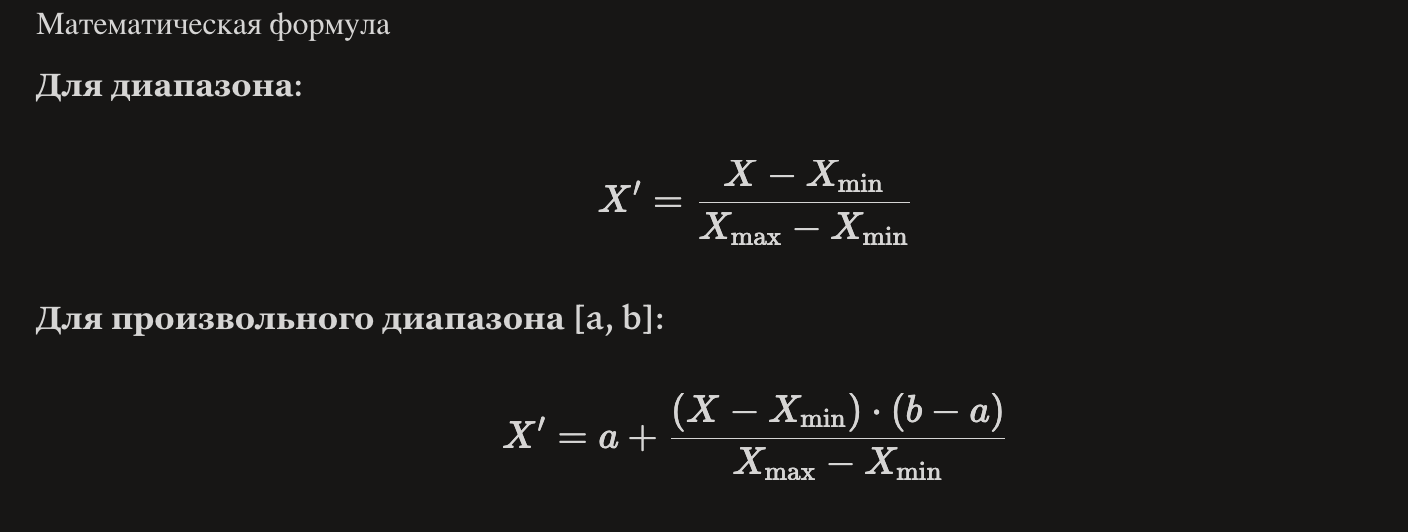

In [312]:
def MinMax(x, x_min, x_max):
    x_scaled = (x - x_min) / (x_max - x_min)
    return x_scaled

In [310]:
X_min = X_train.min()
X_max = X_train.max()

In [315]:
X_train_scaled = MinMax(X_train, X_min, X_max)
X_train_scaled

,bathrooms,bedrooms,Elevator,Cats Allowed,Hardwood Floors,Dogs Allowed,Doorman,Dishwasher,No Fee,Laundry in Building,...,Laundry in Unit,Roof Deck,Outdoor Space,Dining Room,High Speed Internet,Balcony,Swimming Pool,Laundry In Building,New Construction,Terrace
4,0.10,0.125,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.10,0.250,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.10,0.250,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,0.15,0.375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15,0.10,0.000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,0.10,0.375,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
124002,0.10,0.250,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
124004,0.10,0.125,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
124008,0.10,0.250,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [317]:
scaler = MinMaxScaler()

X_train_sk = scaler.fit_transform(X_train)
X_train_sk

array([[0.1  , 0.125, 0.   , ..., 0.   , 0.   , 0.   ],
       [0.1  , 0.25 , 1.   , ..., 0.   , 0.   , 0.   ],
       [0.1  , 0.25 , 1.   , ..., 0.   , 0.   , 0.   ],
       ...,
       [0.1  , 0.125, 1.   , ..., 0.   , 0.   , 0.   ],
       [0.1  , 0.25 , 0.   , ..., 0.   , 0.   , 0.   ],
       [0.1  , 0.375, 1.   , ..., 0.   , 0.   , 0.   ]], shape=(49352, 22))

##### Standard Scaler

![Снимок экрана 2026-04-06 в 10.39.43.png](<attachment:Снимок экрана 2026-04-06 в 10.39.43.png>)
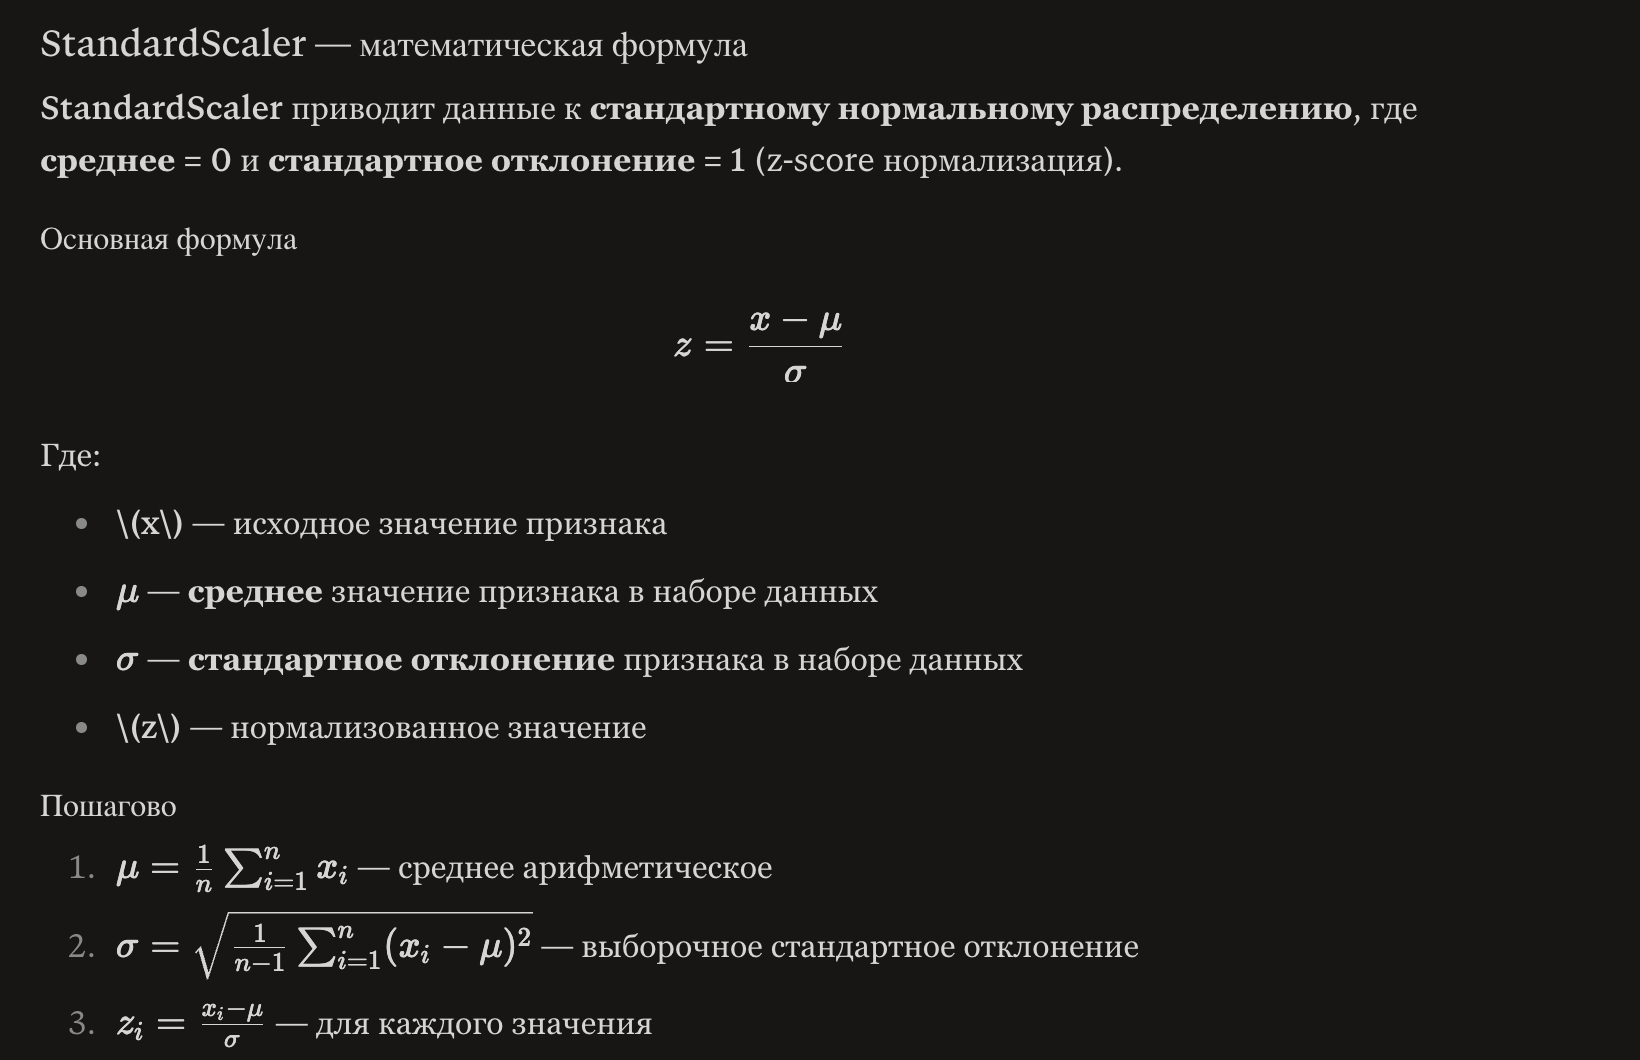

In [ ]:
def Standard(x, x_mean, s):
    z = (x - x_mean)/ s

    return z

In [325]:
x_avg = X_train.mean()
s = X_train.std(ddof=0)

X_train_standard = Standard(X_train, x_avg, s)
X_train_scaled

,bathrooms,bedrooms,Elevator,Cats Allowed,Hardwood Floors,Dogs Allowed,Doorman,Dishwasher,No Fee,Laundry in Building,...,Laundry in Unit,Roof Deck,Outdoor Space,Dining Room,High Speed Internet,Balcony,Swimming Pool,Laundry In Building,New Construction,Terrace
4,0.10,0.125,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.10,0.250,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.10,0.250,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,0.15,0.375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15,0.10,0.000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,0.10,0.375,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
124002,0.10,0.250,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
124004,0.10,0.125,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
124008,0.10,0.250,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [322]:
scaled = StandardScaler()

X_train_standard_sk = scaled.fit_transform(X_train)
X_train_standard_sk

array([[-0.42316255, -0.48577234, -1.05153709, ..., -0.23548793,
        -0.23385394, -0.22023456],
       [-0.42316255,  0.41108287,  0.9509888 , ..., -0.23548793,
        -0.23385394, -0.22023456],
       [-0.42316255,  0.41108287,  0.9509888 , ..., -0.23548793,
        -0.23385394, -0.22023456],
       ...,
       [-0.42316255, -0.48577234,  0.9509888 , ..., -0.23548793,
        -0.23385394, -0.22023456],
       [-0.42316255,  0.41108287, -1.05153709, ..., -0.23548793,
        -0.23385394, -0.22023456],
       [-0.42316255,  1.30793808,  0.9509888 , ..., -0.23548793,
        -0.23385394, -0.22023456]], shape=(49352, 22))

In [324]:
np.allclose(X_train_scaled, X_train_sk)

True

In [326]:
np.allclose(X_train_standard, X_train_standard_sk)

True

#### Fit custom and sklearn models with normalized data

Обучите все модели — `линейную регрессию`, `Ridge`, `Lasso` и `ElasticNet` — с помощью `MinMaxScaler`.


Обучите все модели — `линейную регрессию`, `Ridge`, `Lasso` и `ElasticNet` — с помощью `StandardScaler`.


Добавьте все результаты в наш фрейм данных с метриками по выборкам.

##### MinMaxScaler 

In [334]:
scaler_minmax = MinMaxScaler()

X_train_minmax = scaler_minmax.fit_transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)

In [336]:
lr = LinearRegression()
ridge = Ridge(alpha=0.01)
lasso = Lasso(alpha=0.01)
el = ElasticNet(alpha=0.01)

lr.fit(X_train_minmax, y_train)
ridge.fit(X_train_minmax, y_train)
lasso.fit(X_train_minmax, y_train)
el.fit(X_train_minmax, y_train)

pred_lr_train = lr.predict(X_train_minmax)
pred_lr_test = lr.predict(X_test_minmax)

pred_ridge_train = ridge.predict(X_train_minmax)
pred_ridge_test = ridge.predict(X_test_minmax)

pred_lasso_train = lasso.predict(X_train_minmax)
pred_lasso_test = lasso.predict(X_test_minmax)

pred_elastic_train = el.predict(X_train_minmax)
pred_elastic_test = el.predict(X_test_minmax)

In [339]:
mae_lr_train = mean_absolute_error(y_train, pred_lr_train)
mae_lr_test = mean_absolute_error(y_test, pred_lr_test)

rmse_lr_train = np.sqrt(np.mean((y_train - pred_lr_train)**2))
rmse_lr_test = np.sqrt(np.mean((y_test - pred_lr_test)**2))

r2_lr_train = r2_score(y_train, pred_lr_train)
r2_lr_test = r2_score(y_test, pred_lr_test)

df_mae.loc[len(df_mae)] = ['linear_minmax', mae_lr_train, mae_lr_test]
df_rmse.loc[len(df_rmse)] = ['linear_minmax', rmse_lr_train, rmse_lr_test]
df_r2.loc[len(df_r2)] = ['linear_minmax', r2_lr_train, r2_lr_test]

In [340]:
mae_lr_train = mean_absolute_error(y_train, pred_lr_train)
mae_lr_test = mean_absolute_error(y_test, pred_lr_test)

rmse_lr_train = np.sqrt(np.mean((y_train - pred_lr_train)**2))
rmse_lr_test = np.sqrt(np.mean((y_test - pred_lr_test)**2))

r2_lr_train = r2_score(y_train, pred_lr_train)
r2_lr_test = r2_score(y_test, pred_lr_test)

df_mae.loc[len(df_mae)] = ['linear_minmax', mae_lr_train, mae_lr_test]
df_rmse.loc[len(df_rmse)] = ['linear_minmax', rmse_lr_train, rmse_lr_test]
df_r2.loc[len(df_r2)] = ['linear_minmax', r2_lr_train, r2_lr_test]

In [341]:
pred_ridge_train = ridge.predict(X_train_minmax)
pred_ridge_test = ridge.predict(X_test_minmax)

mae_ridge_train = mean_absolute_error(y_train, pred_ridge_train)
mae_ridge_test = mean_absolute_error(y_test, pred_ridge_test)

rmse_ridge_train = np.sqrt(np.mean((y_train - pred_ridge_train)**2))
rmse_ridge_test = np.sqrt(np.mean((y_test - pred_ridge_test)**2))

r2_ridge_train = r2_score(y_train, pred_ridge_train)
r2_ridge_test = r2_score(y_test, pred_ridge_test)

df_mae.loc[len(df_mae)] = ['ridge_minmax', mae_ridge_train, mae_ridge_test]
df_rmse.loc[len(df_rmse)] = ['ridge_minmax', rmse_ridge_train, rmse_ridge_test]
df_r2.loc[len(df_r2)] = ['ridge_minmax', r2_ridge_train, r2_ridge_test]

In [342]:
pred_elastic_train = el.predict(X_train_minmax)
pred_elastic_test = el.predict(X_test_minmax)

mae_elastic_train = mean_absolute_error(y_train, pred_elastic_train)
mae_elastic_test = mean_absolute_error(y_test, pred_elastic_test)

rmse_elastic_train = np.sqrt(np.mean((y_train - pred_elastic_train)**2))
rmse_elastic_test = np.sqrt(np.mean((y_test - pred_elastic_test)**2))

r2_elastic_train = r2_score(y_train, pred_elastic_train)
r2_elastic_test = r2_score(y_test, pred_elastic_test)

df_mae.loc[len(df_mae)] = ['elastic_minmax', mae_elastic_train, mae_elastic_test]
df_rmse.loc[len(df_rmse)] = ['elastic_minmax', rmse_elastic_train, rmse_elastic_test]
df_r2.loc[len(df_r2)] = ['elastic_minmax', r2_elastic_train, r2_elastic_test]

##### StandardSclaer

In [343]:
scaler_standard = StandardScaler()

X_train_standard = scaler_standard.fit_transform(X_train)
X_test_standard = scaler_standard.transform(X_test)

In [344]:
lr_st = LinearRegression()
ridge_st = Ridge(alpha=0.01)
lasso_st = Lasso(alpha=0.01)
el_st = ElasticNet(alpha=0.01)


lr_st.fit(X_train_standard, y_train)
ridge_st.fit(X_train_standard, y_train)
lasso_st.fit(X_train_standard, y_train)
el_st.fit(X_train_standard, y_train)

pred_lr_train_st = lr_st.predict(X_train_standard)
pred_lr_test_st = lr_st.predict(X_test_standard)

pred_ridge_train_st = ridge_st.predict(X_train_standard)
pred_ridge_test_st = ridge_st.predict(X_test_standard)

pred_lasso_train_st = lasso_st.predict(X_train_standard)
pred_lasso_test_st = lasso_st.predict(X_test_standard)

pred_el_train_st = el_st.predict(X_train_standard)
pred_el_test_st = el_st.predict(X_test_standard)

In [345]:
mae_lr_train_st = mean_absolute_error(y_train, pred_lr_train_st)
mae_lr_test_st = mean_absolute_error(y_test, pred_lr_test_st)

rmse_lr_train_st = np.sqrt(np.mean((y_train - pred_lr_train_st)**2))
rmse_lr_test_st = np.sqrt(np.mean((y_test - pred_lr_test_st)**2))

r2_lr_train_st = r2_score(y_train, pred_lr_train_st)
r2_lr_test_st = r2_score(y_test, pred_lr_test_st)

df_mae.loc[len(df_mae)] = ['linear_standard', mae_lr_train_st, mae_lr_test_st]
df_rmse.loc[len(df_rmse)] = ['linear_standard', rmse_lr_train_st, rmse_lr_test_st]
df_r2.loc[len(df_r2)] = ['linear_standard', r2_lr_train_st, r2_lr_test_st]

In [346]:
mae_ridge_train_st = mean_absolute_error(y_train, pred_ridge_train_st)
mae_ridge_test_st = mean_absolute_error(y_test, pred_ridge_test_st)

rmse_ridge_train_st = np.sqrt(np.mean((y_train - pred_ridge_train_st)**2))
rmse_ridge_test_st = np.sqrt(np.mean((y_test - pred_ridge_test_st)**2))

r2_ridge_train_st = r2_score(y_train, pred_ridge_train_st)
r2_ridge_test_st = r2_score(y_test, pred_ridge_test_st)

df_mae.loc[len(df_mae)] = ['ridge_standard', mae_ridge_train_st, mae_ridge_test_st]
df_rmse.loc[len(df_rmse)] = ['ridge_standard', rmse_ridge_train_st, rmse_ridge_test_st]
df_r2.loc[len(df_r2)] = ['ridge_standard', r2_ridge_train_st, r2_ridge_test_st]

In [347]:
mae_lasso_train_st = mean_absolute_error(y_train, pred_lasso_train_st)
mae_lasso_test_st = mean_absolute_error(y_test, pred_lasso_test_st)

rmse_lasso_train_st = np.sqrt(np.mean((y_train - pred_lasso_train_st)**2))
rmse_lasso_test_st = np.sqrt(np.mean((y_test - pred_lasso_test_st)**2))

r2_lasso_train_st = r2_score(y_train, pred_lasso_train_st)
r2_lasso_test_st = r2_score(y_test, pred_lasso_test_st)

df_mae.loc[len(df_mae)] = ['lasso_standard', mae_lasso_train_st, mae_lasso_test_st]
df_rmse.loc[len(df_rmse)] = ['lasso_standard', rmse_lasso_train_st, rmse_lasso_test_st]
df_r2.loc[len(df_r2)] = ['lasso_standard', r2_lasso_train_st, r2_lasso_test_st]

In [348]:
mae_el_train_st = mean_absolute_error(y_train, pred_el_train_st)
mae_el_test_st = mean_absolute_error(y_test, pred_el_test_st)

rmse_el_train_st = np.sqrt(np.mean((y_train - pred_el_train_st)**2))
rmse_el_test_st = np.sqrt(np.mean((y_test - pred_el_test_st)**2))

r2_el_train_st = r2_score(y_train, pred_el_train_st)
r2_el_test_st = r2_score(y_test, pred_el_test_st)

df_mae.loc[len(df_mae)] = ['elastic_standard', mae_el_train_st, mae_el_test_st]
df_rmse.loc[len(df_rmse)] = ['elastic_standard', rmse_el_train_st, rmse_el_test_st]
df_r2.loc[len(df_r2)] = ['elastic_standard', r2_el_train_st, r2_el_test_st]

In [349]:
df_mae

,model,train,test
0,simple_model,1912.717898,1832.614911
1,sk_model,1155.270725,1085.825554
2,model_ridge,1913.524106,1913.524106
3,model_lasso,1912.723619,1912.723619
4,model_elasticnet,1913.529825,1913.529825
5,model_ridge_sk,1155.270226,1085.825041
6,model_lasso_sk,1155.232450,1085.785561
7,model_elastic_sk,1144.140350,1074.414161
8,linear_minmax,1155.270725,1085.825554
9,linear_minmax,1155.270725,1085.825554


In [350]:
df_rmse

,model,train,test
0,simple_model,22112.959487,9807.894289
1,sk_model,21995.071938,9619.841338
2,model_ridge,22113.042523,22113.042523
3,model_lasso,22112.960044,22112.960044
4,model_elasticnet,22113.043080,22113.043080
5,model_ridge_sk,21995.071938,9619.841226
6,model_lasso_sk,21995.071939,9619.838886
7,model_elastic_sk,21995.115772,9617.273160
8,linear_minmax,21995.071938,9619.841338
9,linear_minmax,21995.071938,9619.841338


In [351]:
df_r2

,model,train,test
0,simple_model,-0.004202,-0.019630
1,sk_model,0.006476,0.019096
2,model_ridge,-0.004210,-0.004210
3,model_lasso,-0.004202,-0.004202
4,model_elasticnet,-0.004210,-0.004210
5,model_ridge_sk,0.006476,0.019096
6,model_lasso_sk,0.006476,0.019096
7,model_elastic_sk,0.006472,0.019619
8,linear_minmax,0.006476,0.019096
9,linear_minmax,0.006476,0.019096


#### Overfit models

Давайте рассмотрим перенастроенную модель на практике. Из теории вы знаете, что полиномиальную регрессию легко перенастроить. Итак, давайте создадим игрушечный пример и посмотрим, как регуляризация работает в реальной жизни.


На предыдущем уроке мы создали полиномиальные объекты со степенью 10. Здесь мы повторяем шаги из предыдущего урока, помня, что у нас есть только 2 основных объекта — "ванные комнаты" и "спальни".


А также обучить и подогнать все реализованные нами алгоритмы — линейной регрессии, Ridge, Lasso и ElasticNet — к набору полиномиальных функций.


Сохраняйте результаты измерений качества в результирующем фрейме данных.


Проанализируйте результаты и выберите лучшую модель, на ваш взгляд.


Дополнительно попробуйте различные альфа-параметры регуляризации в алгоритмах, выберите лучший из них и проанализируйте результаты.

In [366]:
poly = PolynomialFeatures(degree=10)

X_train_poly = poly.fit_transform(X_train[["bathrooms", "bedrooms"]])
X_test_poly = poly.transform(X_test[["bathrooms", "bedrooms"]])

In [365]:
type(X_train_poly)

numpy.ndarray

In [367]:
lr = LinearRegression()
ridge = Ridge(alpha=0.01)
lasso = Lasso(alpha=0.01)
el = ElasticNet(alpha=0.01)

lr.fit(X_train_poly, y_train)
ridge.fit(X_train_poly, y_train)
lasso.fit(X_train_poly, y_train)
el.fit(X_train_poly, y_train)

pred_lr_train_poly = lr.predict(X_train_poly)
pred_lr_test_poly = lr.predict(X_test_poly)

pred_ridge_train_poly = ridge.predict(X_train_poly)
pred_ridge_test_poly = ridge.predict(X_test_poly)

pred_lasso_train_poly = lasso.predict(X_train_poly)
pred_lasso_test_poly = lasso.predict(X_test_poly)

pred_el_train_poly = el.predict(X_train_poly)
pred_el_test_poly = el.predict(X_test_poly)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.194e+13, tolerance: 2.403e+09
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.194e+13, tolerance: 2.403e+09
  model = cd_fast.enet_coordinate_descent(


In [368]:
mae_lr_train_poly = mean_absolute_error(y_train, pred_lr_train_poly)
mae_lr_test_poly = mean_absolute_error(y_test, pred_lr_test_poly)

rmse_lr_train_poly = np.sqrt(np.mean((y_train - pred_lr_train_poly)**2))
rmse_lr_test_poly = np.sqrt(np.mean((y_test - pred_lr_test_poly)**2))

r2_lr_train_poly = r2_score(y_train, pred_lr_train_poly)
r2_lr_test_poly = r2_score(y_test, pred_lr_test_poly)

df_mae.loc[len(df_mae)] = ['linear_poly', mae_lr_train_poly, mae_lr_test_poly]
df_rmse.loc[len(df_rmse)] = ['linear_poly', rmse_lr_train_poly, rmse_lr_test_poly]
df_r2.loc[len(df_r2)] = ['linear_poly', r2_lr_train_poly, r2_lr_test_poly]

In [ ]:
mae_ridge_train_poly = mean_absolute_error(y_train, pred_ridge_train_poly)
mae_ridge_test_poly = mean_absolute_error(y_test, pred_ridge_test_poly)

rmse_ridge_train_poly = np.sqrt(np.mean((y_train - pred_ridge_train_poly)**2))
rmse_ridge_test_poly = np.sqrt(np.mean((y_test - pred_ridge_test_poly)**2))

r2_ridge_train_poly = r2_score(y_train, pred_ridge_train_poly)
r2_ridge_test_poly = r2_score(y_test, pred_ridge_test_poly)


df_mae.loc[len(df_mae)] = ['ridge_poly', mae_ridge_train_poly, mae_ridge_test_poly]
df_rmse.loc[len(df_rmse)] = ['ridge_poly', rmse_ridge_train_poly, rmse_ridge_test_poly]
df_r2.loc[len(df_r2)] = ['ridge_poly', r2_ridge_train_poly, r2_ridge_test_poly]

`alpha` = 0.01

1060.0893859016364          3.368898273154984e+16


21993.292214235975          9.205109824207295e+18


0.006637003794825569        -8.981498379274159e+29


`alpha` = 0.001

1059.9407722213696          8.336806803208006e+16


21993.1668413317            2.2779323082799608e+19


0.00664832910689328        -5.50012393716785e+30



`alpha` = 0.0001

1059.699760614579           1.062491999959043e+17


21993.119356094387          2.9031317495052304e+19


0.0066526185745489075       -8.933555460648477e+30



`alpha` = 0.1

1059.9091786692047          1.3793890452265728e+16


21993.380634153105          3.7690148567940844e+18


0.006629016518568176        -1.505728067375803e+29



`alpha` = 1

1059.4233819065262          1.5451957353227664e+16


21993.43550451333           4.222061720970539e+18


0.006624059873421184       -1.8894700087852154e+29



In [370]:
mae_lasso_train_poly = mean_absolute_error(y_train, pred_lasso_train_poly)
mae_lasso_test_poly = mean_absolute_error(y_test, pred_lasso_test_poly)

rmse_lasso_train_poly = np.sqrt(np.mean((y_train - pred_lasso_train_poly)**2))
rmse_lasso_test_poly = np.sqrt(np.mean((y_test - pred_lasso_test_poly)**2))

r2_lasso_train_poly = r2_score(y_train, pred_lasso_train_poly)
r2_lasso_test_poly = r2_score(y_test, pred_lasso_test_poly)

df_mae.loc[len(df_mae)] = ['lasso_poly', mae_lasso_train_poly, mae_lasso_test_poly]
df_rmse.loc[len(df_rmse)] = ['lasso_poly', rmse_lasso_train_poly, rmse_lasso_test_poly]
df_r2.loc[len(df_r2)] = ['lasso_poly', r2_lasso_train_poly, r2_lasso_test_poly]

In [371]:
mae_el_train_poly = mean_absolute_error(y_train, pred_el_train_poly)
mae_el_test_poly = mean_absolute_error(y_test, pred_el_test_poly)

rmse_el_train_poly = np.sqrt(np.mean((y_train - pred_el_train_poly)**2))
rmse_el_test_poly = np.sqrt(np.mean((y_test - pred_el_test_poly)**2))

r2_el_train_poly = r2_score(y_train, pred_el_train_poly)
r2_el_test_poly = r2_score(y_test, pred_el_test_poly)

df_mae.loc[len(df_mae)] = ['elastic_poly', mae_el_train_poly, mae_el_test_poly]
df_rmse.loc[len(df_rmse)] = ['elastic_poly', rmse_el_train_poly, rmse_el_test_poly]
df_r2.loc[len(df_r2)] = ['elastic_poly', r2_el_train_poly, r2_el_test_poly]

In [372]:
df_mae

,model,train,test
0,simple_model,1912.717898,1.832615e+03
1,sk_model,1155.270725,1.085826e+03
2,model_ridge,1913.524106,1.913524e+03
3,model_lasso,1912.723619,1.912724e+03
4,model_elasticnet,1913.529825,1.913530e+03
5,model_ridge_sk,1155.270226,1.085825e+03
6,model_lasso_sk,1155.232450,1.085786e+03
7,model_elastic_sk,1144.140350,1.074414e+03
8,linear_minmax,1155.270725,1.085826e+03
9,linear_minmax,1155.270725,1.085826e+03


In [373]:
df_rmse

,model,train,test
0,simple_model,22112.959487,9.807894e+03
1,sk_model,21995.071938,9.619841e+03
2,model_ridge,22113.042523,2.211304e+04
3,model_lasso,22112.960044,2.211296e+04
4,model_elasticnet,22113.043080,2.211304e+04
5,model_ridge_sk,21995.071938,9.619841e+03
6,model_lasso_sk,21995.071939,9.619839e+03
7,model_elastic_sk,21995.115772,9.617273e+03
8,linear_minmax,21995.071938,9.619841e+03
9,linear_minmax,21995.071938,9.619841e+03


In [374]:
df_r2

,model,train,test
0,simple_model,-0.004202,-1.962952e-02
1,sk_model,0.006476,1.909564e-02
2,model_ridge,-0.004210,-4.209883e-03
3,model_lasso,-0.004202,-4.202392e-03
4,model_elasticnet,-0.004210,-4.209933e-03
5,model_ridge_sk,0.006476,1.909566e-02
6,model_lasso_sk,0.006476,1.909614e-02
7,model_elastic_sk,0.006472,1.961931e-02
8,linear_minmax,0.006476,1.909564e-02
9,linear_minmax,0.006476,1.909564e-02


#### Native models

In [393]:
maen_value = y_train.mean()
median_value = y_train.median()

In [395]:
pred_mean_train = np.full(len(y_train), maen_value)
pred_mean_test = np.full(len(y_test), maen_value)

pred_median_train = np.full(len(y_train), median_value)
pred_median_test = np.full(len(y_test), median_value)

In [396]:
mae_mean_train = mean_absolute_error(y_train, pred_mean_train)
mae_mean_test = mean_absolute_error(y_test, pred_mean_test)

rmse_mean_train = np.sqrt(np.mean((y_train - pred_mean_train)**2))
rmse_mean_test = np.sqrt(np.mean((y_test - pred_mean_test)**2))

r2_mean_train = r2_score(y_train, pred_mean_train)
r2_mean_test = r2_score(y_test, pred_mean_test)

In [397]:
df_mae.loc[len(df_mae)] = ['mean_model', mae_mean_train, mae_mean_test]
df_rmse.loc[len(df_rmse)] = ['mean_model', rmse_mean_train, rmse_mean_test]
df_r2.loc[len(df_r2)] = ['mean_model', r2_mean_train, r2_mean_test]

In [398]:
mae_median_train = mean_absolute_error(y_train, pred_median_train)
mae_median_test = mean_absolute_error(y_test, pred_median_test)

rmse_median_train = np.sqrt(np.mean((y_train - pred_median_train)**2))
rmse_median_test = np.sqrt(np.mean((y_test - pred_median_test)**2))

r2_median_train = r2_score(y_train, pred_median_train)
r2_median_test = r2_score(y_test, pred_median_test)

In [399]:
df_mae.loc[len(df_mae)] = ['median_model', mae_median_train, mae_median_test]
df_rmse.loc[len(df_rmse)] = ['median_model', rmse_median_train, rmse_median_test]
df_r2.loc[len(df_r2)] = ['median_model', r2_median_train, r2_median_test]

#### Compare results

In [400]:
df_mae

,model,train,test
0,simple_model,1912.717898,1.832615e+03
1,sk_model,1155.270725,1.085826e+03
2,model_ridge,1913.524106,1.913524e+03
3,model_lasso,1912.723619,1.912724e+03
4,model_elasticnet,1913.529825,1.913530e+03
5,model_ridge_sk,1155.270226,1.085825e+03
6,model_lasso_sk,1155.232450,1.085786e+03
7,model_elastic_sk,1144.140350,1.074414e+03
8,linear_minmax,1155.270725,1.085826e+03
9,linear_minmax,1155.270725,1.085826e+03


In [401]:
df_rmse

,model,train,test
0,simple_model,22112.959487,9.807894e+03
1,sk_model,21995.071938,9.619841e+03
2,model_ridge,22113.042523,2.211304e+04
3,model_lasso,22112.960044,2.211296e+04
4,model_elasticnet,22113.043080,2.211304e+04
5,model_ridge_sk,21995.071938,9.619841e+03
6,model_lasso_sk,21995.071939,9.619839e+03
7,model_elastic_sk,21995.115772,9.617273e+03
8,linear_minmax,21995.071938,9.619841e+03
9,linear_minmax,21995.071938,9.619841e+03


In [402]:
df_r2

,model,train,test
0,simple_model,-0.004202,-1.962952e-02
1,sk_model,0.006476,1.909564e-02
2,model_ridge,-0.004210,-4.209883e-03
3,model_lasso,-0.004202,-4.202392e-03
4,model_elasticnet,-0.004210,-4.209933e-03
5,model_ridge_sk,0.006476,1.909566e-02
6,model_lasso_sk,0.006476,1.909614e-02
7,model_elastic_sk,0.006472,1.961931e-02
8,linear_minmax,0.006476,1.909564e-02
9,linear_minmax,0.006476,1.909564e-02


In [403]:
top_5_mae = df_mae.sort_values(by="test", ascending=True).head(5)
top_5_mae

,model,train,test
7,model_elastic_sk,1144.140350,1074.414161
15,elastic_standard,1152.573908,1083.063316
6,model_lasso_sk,1155.232450,1085.785561
14,lasso_standard,1155.254391,1085.808522
10,ridge_minmax,1155.269336,1085.823495


In [ ]:
top_5_rmse = df_rmse.sort_values(by="test", ascending=True).head(5)
top_5_rmse

,model,train,test
17,ridge_poly,21993.292214,9.205110e+18
16,linear_poly,21993.392006,2.580631e+18
18,lasso_poly,21996.763623,1.756545e+13
19,elastic_poly,21996.856206,1.473908e+13
4,model_elasticnet,22113.043080,2.211304e+04


In [420]:
top_5_r2 = df_r2.sort_values(by="test", ascending=False).head(5)
top_5_r2

,model,train,test
11,elastic_minmax,0.005563,0.021907
7,model_elastic_sk,0.006472,0.019619
15,elastic_standard,0.006476,0.019216
10,ridge_minmax,0.006476,0.019098
6,model_lasso_sk,0.006476,0.019096


In [407]:
df_mae['diff'] = df_mae['train'] - df_mae['test']
df_mae['abs_diff'] = df_mae['diff'].abs()


top5_mae_stable = df_mae.sort_values(by=['test', 'abs_diff'], ascending=[True, True]).head(5)
top5_mae_stable

,model,train,test,diff,abs_diff
7,model_elastic_sk,1144.140350,1074.414161,69.726189,69.726189
15,elastic_standard,1152.573908,1083.063316,69.510592,69.510592
6,model_lasso_sk,1155.232450,1085.785561,69.446889,69.446889
14,lasso_standard,1155.254391,1085.808522,69.445869,69.445869
10,ridge_minmax,1155.269336,1085.823495,69.445841,69.445841


In [427]:
df_metrics = pd.DataFrame({
    "MAE_test": df_mae["test"],
    "MAE_abs": (df_mae["train"] - df_mae["test"]).abs(),
    "RMSE_test": df_rmse["test"],
    "RMSE_abs": (df_rmse["train"] - df_rmse["test"]).abs(),
    "R2_test": df_r2["test"],
    "R2_abs": (df_r2["train"] - df_r2["test"]).abs()

})

top5_all = df_metrics.sort_values(
    by=["R2_test", "MAE_test", "RMSE_test"],
    ascending=[False, True, True]
).head(5)

top5_all

,MAE_test,MAE_abs,RMSE_test,RMSE_abs,R2_test,R2_abs
11,1125.033951,75.720972,9606.045999,12399.132237,0.021907,0.016344
7,1074.414161,69.726189,9617.273160,12377.842613,0.019619,0.013147
15,1083.063316,69.510592,9619.248938,12375.825094,0.019216,0.012740
10,1085.823495,69.445841,9619.832141,12375.239798,0.019098,0.012621
6,1085.785561,69.446889,9619.838886,12375.233053,0.019096,0.012620


#### Addition task

Есть несколько хитростей с целевой переменной для улучшения качества модели. Если у нас распределение с большим хвостом, вы можете использовать `монотонную функцию`, чтобы `"улучшить" распределение`. На практике вы можете использовать `логарифмические функции`. Мы рекомендуем вам выполнить это упражнение и сравнить результаты. Но не забудьте выполнить обратное преобразование, если вы хотите сравнить показатели.


`Следующий трюк - это выбросы`. Угол наклона линии линейной регрессии сильно зависит от выбросов. И часто вам следует удалять эти точки из `!allert!` только из обучающих данных. Вам следует объяснить, почему они были удалены только из обучающей выборки. Мы рекомендуем вам выполнить это упражнение и сравнить результаты.


Это также будет полезным упражнением для реализации алгоритма линейной регрессии с пакетным и мини-пакетным обучением или аналитическим решением (как указано в 4.1).

##### Logarthmic function

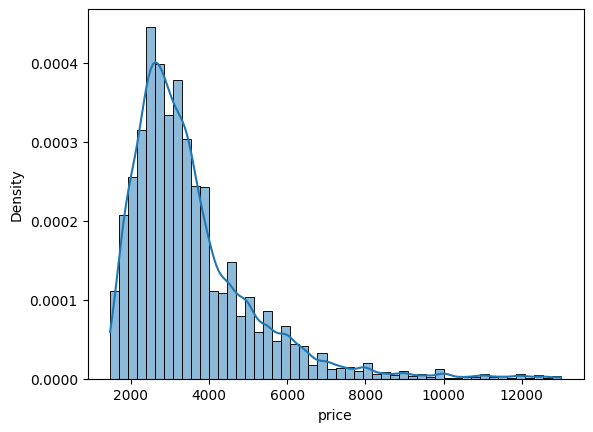

In [440]:
import seaborn as sns

df_check = df_train[(df_train["price"] >= df_train["price"].quantile(0.01) ) & (df_train["price"] <= df_train["price"].quantile(0.99))]

sns.histplot(df_check["price"], bins=50, kde=True, stat="density")
plt.show()

In [441]:
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

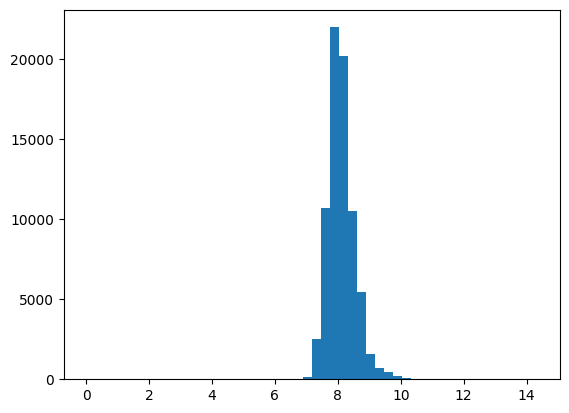

In [446]:
plt.hist(
    y_test_log,
    bins=50
)

plt.show()

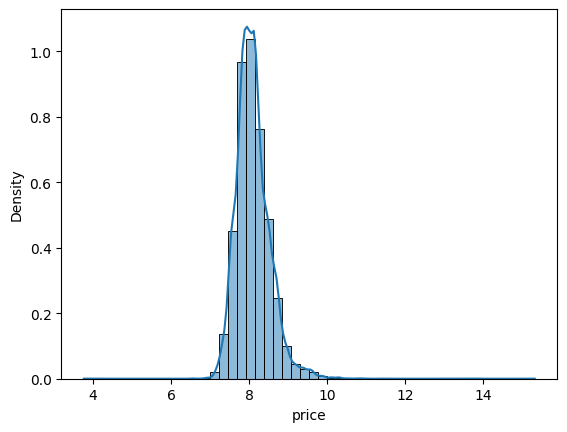

In [447]:
sns.histplot(y_train_log, bins=50, kde=True, stat="density")

plt.show()

In [449]:
lr = LinearRegression()

lr.fit(X_train, y_train_log)

pred_train_log = lr.predict(X_train)
pred_test_log = lr.predict(X_test)

In [450]:
pred_train = np.expm1(pred_train_log)
pred_test = np.expm1(pred_test_log)

In [453]:
mae_train = mean_absolute_error(y_train, pred_train)
mae_test = mean_absolute_error(y_test, pred_test)


rmse_train = np.sqrt(np.mean((y_train - pred_train)**2))
rmse_test = np.sqrt(np.mean((y_test - pred_test)**2))


r2_train = r2_score(y_train, pred_train)
r2_test = r2_score(y_test, pred_test)

print("             Train               Test")
print(f"MAE:    {mae_train}    {mae_test}")
print(f"RMSE:   {rmse_train}  {rmse_test}")
print(f"R2:     {r2_train}  {r2_test}")

             Train               Test
MAE:    954.1803372334538    177303982026759.34
RMSE:   21997.618593287632  4.844618393403099e+16
R2:     0.006246149390664035  -2.4877686724089643e+25


In [460]:
df_mae

,model,train,test,diff,abs_diff
0,simple_model,1912.717898,1.832615e+03,8.010299e+01,8.010299e+01
1,sk_model,1155.270725,1.085826e+03,6.944517e+01,6.944517e+01
2,model_ridge,1913.524106,1.913524e+03,0.000000e+00,0.000000e+00
3,model_lasso,1912.723619,1.912724e+03,0.000000e+00,0.000000e+00
4,model_elasticnet,1913.529825,1.913530e+03,0.000000e+00,0.000000e+00
5,model_ridge_sk,1155.270226,1.085825e+03,6.944518e+01,6.944518e+01
6,model_lasso_sk,1155.232450,1.085786e+03,6.944689e+01,6.944689e+01
7,model_elastic_sk,1144.140350,1.074414e+03,6.972619e+01,6.972619e+01
8,linear_minmax,1155.270725,1.085826e+03,6.944517e+01,6.944517e+01
9,linear_minmax,1155.270725,1.085826e+03,6.944517e+01,6.944517e+01


In [461]:
df_mae.loc[len(df_mae)] = ['linear_log_target', mae_train, mae_test, mae_test-mae_train, abs(mae_test-mae_train)]
df_rmse.loc[len(df_rmse)] = ['linear_log_target', rmse_train, rmse_test]
df_r2.loc[len(df_r2)] = ['linear_log_target', r2_train, r2_test]

In [462]:
df_mae

,model,train,test,diff,abs_diff
0,simple_model,1912.717898,1.832615e+03,8.010299e+01,8.010299e+01
1,sk_model,1155.270725,1.085826e+03,6.944517e+01,6.944517e+01
2,model_ridge,1913.524106,1.913524e+03,0.000000e+00,0.000000e+00
3,model_lasso,1912.723619,1.912724e+03,0.000000e+00,0.000000e+00
4,model_elasticnet,1913.529825,1.913530e+03,0.000000e+00,0.000000e+00
5,model_ridge_sk,1155.270226,1.085825e+03,6.944518e+01,6.944518e+01
6,model_lasso_sk,1155.232450,1.085786e+03,6.944689e+01,6.944689e+01
7,model_elastic_sk,1144.140350,1.074414e+03,6.972619e+01,6.972619e+01
8,linear_minmax,1155.270725,1.085826e+03,6.944517e+01,6.944517e+01
9,linear_minmax,1155.270725,1.085826e+03,6.944517e+01,6.944517e+01


In [463]:
df_rmse

,model,train,test
0,simple_model,22112.959487,9.807894e+03
1,sk_model,21995.071938,9.619841e+03
2,model_ridge,22113.042523,2.211304e+04
3,model_lasso,22112.960044,2.211296e+04
4,model_elasticnet,22113.043080,2.211304e+04
5,model_ridge_sk,21995.071938,9.619841e+03
6,model_lasso_sk,21995.071939,9.619839e+03
7,model_elastic_sk,21995.115772,9.617273e+03
8,linear_minmax,21995.071938,9.619841e+03
9,linear_minmax,21995.071938,9.619841e+03


In [464]:
df_r2

,model,train,test
0,simple_model,-0.004202,-1.962952e-02
1,sk_model,0.006476,1.909564e-02
2,model_ridge,-0.004210,-4.209883e-03
3,model_lasso,-0.004202,-4.202392e-03
4,model_elasticnet,-0.004210,-4.209933e-03
5,model_ridge_sk,0.006476,1.909566e-02
6,model_lasso_sk,0.006476,1.909614e-02
7,model_elastic_sk,0.006472,1.961931e-02
8,linear_minmax,0.006476,1.909564e-02
9,linear_minmax,0.006476,1.909564e-02


##### Outliers

In [465]:
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [467]:
mask = (y_train >= lower) & (y_train <= upper)

X_train_clean = X_train[mask]
y_train_clean = y_train[mask]

In [468]:
lr = LinearRegression()

lr.fit(X_train_clean, y_train_clean)


pred_train_clean = lr.predict(X_train_clean)
pred_test_clean = lr.predict(X_test)

In [470]:
mae_train_clean = mean_absolute_error(y_train_clean, pred_train_clean)
mae_test_clean = mean_absolute_error(y_test, pred_test_clean)

rmse_train_clean = np.sqrt(np.mean((y_train_clean - pred_train_clean)**2))
rmse_test_clean = np.sqrt(np.mean((y_test - pred_test_clean)**2))


r2_train_clean = r2_score(y_train_clean, pred_train_clean)
r2_test_clean = r2_score(y_test, pred_test_clean)


df_mae.loc[len(df_mae)] = ['linear_clean', mae_train_clean, mae_test_clean, mae_test_clean - mae_train_clean, abs(mae_test_clean - mae_train_clean)]
df_rmse.loc[len(df_rmse)] = ['linear_clean', rmse_train_clean, rmse_test_clean]
df_r2.loc[len(df_r2)] = ['linear_clean', r2_train_clean, r2_test_clean]

In [471]:
df_mae

,model,train,test,diff,abs_diff
0,simple_model,1912.717898,1.832615e+03,8.010299e+01,8.010299e+01
1,sk_model,1155.270725,1.085826e+03,6.944517e+01,6.944517e+01
2,model_ridge,1913.524106,1.913524e+03,0.000000e+00,0.000000e+00
3,model_lasso,1912.723619,1.912724e+03,0.000000e+00,0.000000e+00
4,model_elasticnet,1913.529825,1.913530e+03,0.000000e+00,0.000000e+00
5,model_ridge_sk,1155.270226,1.085825e+03,6.944518e+01,6.944518e+01
6,model_lasso_sk,1155.232450,1.085786e+03,6.944689e+01,6.944689e+01
7,model_elastic_sk,1144.140350,1.074414e+03,6.972619e+01,6.972619e+01
8,linear_minmax,1155.270725,1.085826e+03,6.944517e+01,6.944517e+01
9,linear_minmax,1155.270725,1.085826e+03,6.944517e+01,6.944517e+01


In [472]:
df_rmse

,model,train,test
0,simple_model,22112.959487,9.807894e+03
1,sk_model,21995.071938,9.619841e+03
2,model_ridge,22113.042523,2.211304e+04
3,model_lasso,22112.960044,2.211296e+04
4,model_elasticnet,22113.043080,2.211304e+04
5,model_ridge_sk,21995.071938,9.619841e+03
6,model_lasso_sk,21995.071939,9.619839e+03
7,model_elastic_sk,21995.115772,9.617273e+03
8,linear_minmax,21995.071938,9.619841e+03
9,linear_minmax,21995.071938,9.619841e+03


In [473]:
df_r2

,model,train,test
0,simple_model,-0.004202,-1.962952e-02
1,sk_model,0.006476,1.909564e-02
2,model_ridge,-0.004210,-4.209883e-03
3,model_lasso,-0.004202,-4.202392e-03
4,model_elasticnet,-0.004210,-4.209933e-03
5,model_ridge_sk,0.006476,1.909566e-02
6,model_lasso_sk,0.006476,1.909614e-02
7,model_elastic_sk,0.006472,1.961931e-02
8,linear_minmax,0.006476,1.909564e-02
9,linear_minmax,0.006476,1.909564e-02
